## Dust and Stains Removal from Images

### Project Setup

In [11]:
from pathlib import Path
import random
import shutil
import math
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset

base_path = Path(".")
generated_path = base_path / "generated"
models_path = base_path / "models"
best_model_path = models_path / "unet_mask_guided_best.pth"

seed = 13

split_seed_offsets = {
    "train": 0,
    "validation": 1,
    "test": 2
}

batch_size = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

patch_size = 256

print("Base path:", base_path.resolve())
print("Generated path exists:", generated_path.exists())
print("Best model exists:", best_model_path.exists())
print("Device:", device)

Base path: /home/maia-marin/Dust and Stains Removal from Images
Generated path exists: True
Best model exists: True
Device: cuda


### Data Source

This project uses the [DIV2K Dataset](https://data.vision.ee.ethz.ch/cvl/DIV2K/), a collection of high-quality natural images introduced in the NTIRE 2017 challenge on single-image super-resolution. \
The publicly available portion of the DIV2K dataset contains 800 images intended for training and 100 images intended for validation. \
The images have aproximately 2K resolution and depict a wide variety of scenes, including landscapes, urban environments, people, animals, and objects.

### Dataset Description

Number of images: 900
Width - min: 1116 max: 2040 mean: 1972
Height - min: 648 max: 2040 mean: 1436
Channels: {3}


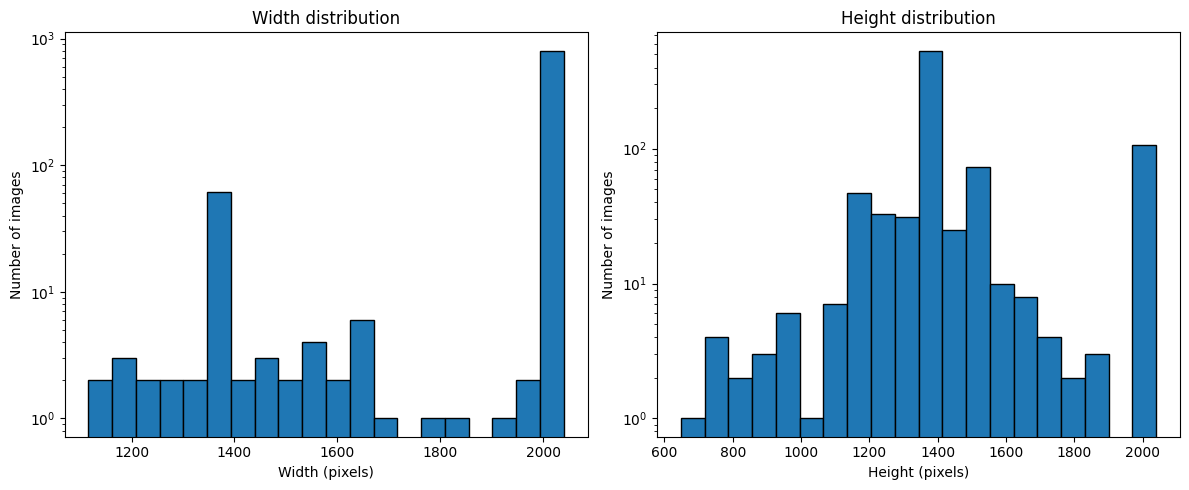

In [4]:
original_folders = {
    "train": base_path / "DIV2K_train_HR",
    "validation": base_path / "DIV2K_valid_HR"
}

widths = []
heights = []
channels = []

for folder in original_folders.values():
    for img_path in sorted(folder.glob("*.png")):
        img = Image.open(img_path).convert("RGB")

        w, h = img.size

        widths.append(w)
        heights.append(h)
        channels.append(len(img.getbands())) # returns no. of distinct channel names

widths = np.array(widths)
heights = np.array(heights)

print("Number of images:", len(widths))
print("Width - min:", widths.min(), "max:", widths.max(), "mean:", int(widths.mean()))
print("Height - min:", heights.min(), "max:", heights.max(), "mean:", int(heights.mean()))
print("Channels:", set(channels))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=20, edgecolor="black")
plt.yscale("log")
plt.title("Width distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Number of images")

plt.subplot(1, 2, 2)
plt.hist(heights, bins=20, edgecolor="black")
plt.yscale("log")
plt.title("Height distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Number of images")

plt.tight_layout()
plt.show()

### Data Preprocessing

#### Train/Validation/Test Split

In [8]:
train_original_folder = base_path / "DIV2K_train_HR"
valid_original_folder = base_path / "DIV2K_valid_HR"

rng = random.Random(seed)

all_train_files = sorted(train_original_folder.glob("*.png"))
all_valid_files = sorted(valid_original_folder.glob("*.png"))

rng.shuffle(all_train_files)

train_files = all_train_files[:700]
val_files = all_train_files[700:800]
test_files = all_valid_files

print("Train images:", len(train_files))
print("Validation images:", len(val_files))
print("Test images:", len(test_files))

print("Example train file:", train_files[0])
print("Example validation file:", val_files[0])
print("Example test file:", test_files[0])

Train images: 700
Validation images: 100
Test images: 100
Example train file: DIV2K_train_HR/0369.png
Example validation file: DIV2K_train_HR/0164.png
Example test file: DIV2K_valid_HR/0801.png


#### Patches Generation

In [9]:
patch_size = 256
patches_per_image = 10

if generated_path.exists():
    shutil.rmtree(generated_path)

split_files = {
    "train": train_files,
    "validation": val_files,
    "test": test_files
}

for split_name in split_files:
    (generated_path / split_name / "clean").mkdir(parents=True, exist_ok=True)

for split_name, files in split_files.items():
    split_rng = random.Random(seed + split_seed_offsets[split_name])
    patch_id = 0

    for img_path in files:
        img = Image.open(img_path).convert("RGB")
        width, height = img.size

        if width < patch_size or height < patch_size:
            continue

        for _ in range(patches_per_image):
            x = split_rng.randint(0, width - patch_size)
            y = split_rng.randint(0, height - patch_size)

            patch = img.crop((x, y, x + patch_size, y + patch_size))
            patch.save(generated_path / split_name / "clean" / f"patch_{patch_id:05d}.png")
            patch_id += 1

    print(f"{split_name} clean patches:", patch_id)

train clean patches: 7000
validation clean patches: 1000
test clean patches: 1000


#### Dust and Stains Addition

In [ ]:
def add_artifacts(img, py_rng, np_rng):
    h, w, _ = img.shape # height, width, no. of channels

    mask = np.zeros((h, w), dtype=np.uint8) # black mask with same dimensions as the image
    corrupted = img.astype(np.float32).copy() # copy of the clean image that will later be modified

    num_random_dust = py_rng.randint(6, 18) # no. of dust particles

    for _ in range(num_random_dust): 
        # (x,y) -> random center point for the dust particle
        x = py_rng.randint(0, w - 1) 
        y = py_rng.randint(0, h - 1)
        # random radius length of the dust particle
        r = py_rng.randint(2, 7)

        # dust will have a random light gray/off-white color
        dust_color_val = py_rng.randint(190, 245)
        dust_color = np.array([dust_color_val, dust_color_val, dust_color_val], dtype=np.float32)

        # transparency strength
        alpha = py_rng.uniform(0.55, 0.95)

        # temporary black image where only dust particles are drawn
        dust_layer = np.zeros((h, w), dtype=np.uint8)
        cv2.circle(dust_layer, (x, y), r, 255, -1)

        # Probability of 50% that a dust particle will be blurred 
        if py_rng.random() < 0.5:
            dust_layer = cv2.GaussianBlur(dust_layer, (5, 5), 0)

        # converts dust layer from 0-255 values to 0-1 values
        # where 0 indicates no dust and 1 indicates no blurring
        dust_strength = dust_layer.astype(np.float32) / 255.0
        # per-pixel opacity map
        alpha_map = dust_strength[..., None] * alpha

        # whever the dust layer is stronger than 10, the mask becomes white
        mask[dust_layer > 10] = 255
        # blending a copy of the original image with the dust color
        # pixels from the original image get the remainder opacity
        # and are summed up with the dust color at the opacity indicated
        # by the opacity map
        corrupted = corrupted * (1 - alpha_map) + dust_color * alpha_map

    num_stains = py_rng.randint(1, 3)

    for _ in range(num_stains):
        stain_layer = np.zeros((h, w), dtype=np.uint8)

        # a stain will be formed from several overlapping circles       
        circles = py_rng.randint(2, 4)
        # initial center and radius of the stain
        cx = py_rng.randint(0, w - 1)
        cy = py_rng.randint(0, h - 1)
        base_radius = py_rng.randint(12, 34)

        # drawing overlapping circles around the main stain center
        for _ in range(circles):
            ox = py_rng.randint(-base_radius, base_radius)
            oy = py_rng.randint(-base_radius, base_radius)
            r = py_rng.randint(max(4, base_radius // 3), base_radius)

            # adding the circles to the stain layer
            cv2.circle(stain_layer, (cx + ox, cy + oy), r, 255, -1)

        # softening the stains to avoid hard edges
        stain_layer = cv2.GaussianBlur(stain_layer, (21, 21), 0)

        # texture map to prevent stains from being perfectly flat/uniform
        texture = np_rng.uniform(0.85, 1.25, size=(h, w)).astype(np.float32)
        stain_strength = np.clip((stain_layer.astype(np.float32) / 255.0) * texture, 0, 1)

        # stain region is added to the mask
        mask[stain_layer > 20] = 255

        # creating a brown/yellow-sih stain color
        stain_color = np.array([
            py_rng.randint(115, 170),
            py_rng.randint(85, 130),
            py_rng.randint(45, 90)
        ], dtype=np.float32)

        # opacity of the stain
        alpha = py_rng.uniform(0.35, 0.70)
        alpha_map = stain_strength[..., None] * alpha

        # blending a copy of the original image with stains
        corrupted = corrupted * (1 - alpha_map) + stain_color * alpha_map

    corrupted = np.clip(corrupted, 0, 255).astype(np.uint8)

    return corrupted, mask

In [12]:
for split_name in ["train", "validation", "test"]:
    clean_dir = generated_path / split_name / "clean"
    corrupted_dir = generated_path / split_name / "corrupted"
    mask_dir = generated_path / split_name / "masks"

    if corrupted_dir.exists():
        shutil.rmtree(corrupted_dir)

    if mask_dir.exists():
        shutil.rmtree(mask_dir)

    corrupted_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    clean_files = sorted(clean_dir.glob("*.png"))

    py_rng = random.Random(seed + split_seed_offsets[split_name] + 100)
    np_rng = np.random.default_rng(seed + split_seed_offsets[split_name] + 100)

    for clean_path in clean_files:
        img = np.array(Image.open(clean_path).convert("RGB"))

        corrupted, mask = add_artifacts(img, py_rng, np_rng)

        Image.fromarray(corrupted).save(corrupted_dir / clean_path.name)
        Image.fromarray(mask).save(mask_dir / clean_path.name)

    print(f"{split_name} corrupted patches:", len(list(corrupted_dir.glob('*.png'))))
    print(f"{split_name} masks:", len(list(mask_dir.glob('*.png'))))

train corrupted patches: 7000
train masks: 7000
validation corrupted patches: 1000
validation masks: 1000
test corrupted patches: 1000
test masks: 1000


#### Corrupted Images Displayal

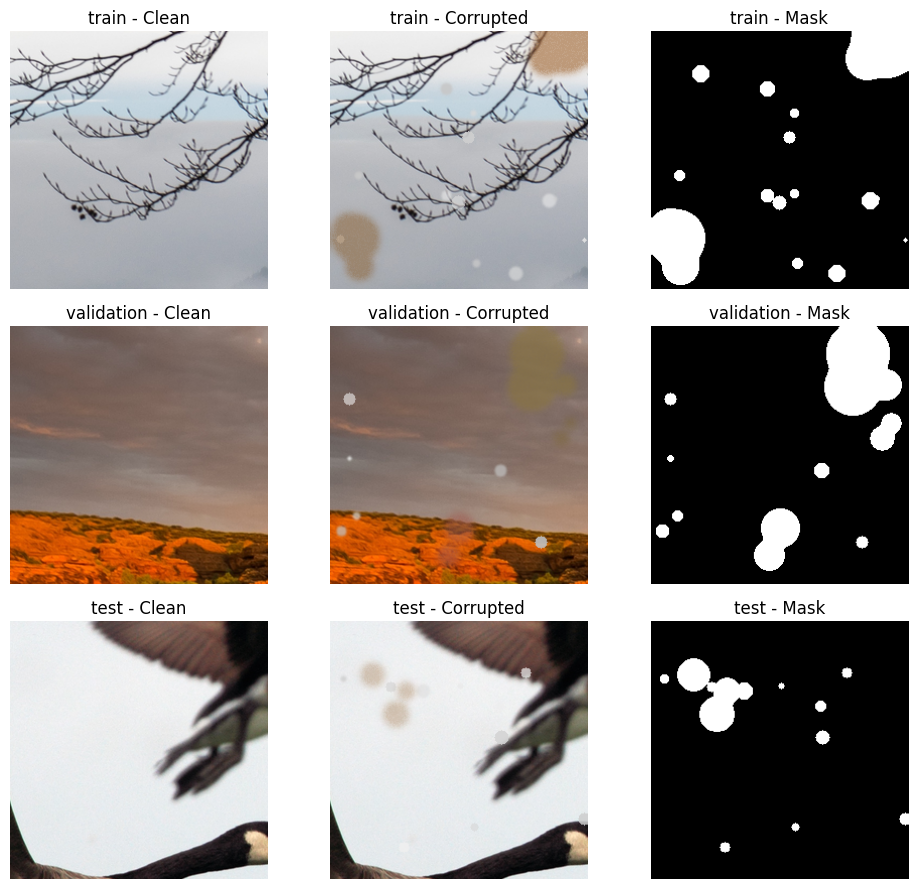

In [36]:
splits = ["train", "validation", "test"]

plt.figure(figsize=(10, 9))

for row, split_name in enumerate(splits):
    clean_dir = generated_path / split_name / "clean"
    corrupted_dir = generated_path / split_name / "corrupted"
    mask_dir = generated_path / split_name / "masks"

    sample_file = random.choice(sorted(clean_dir.glob("*.png")))

    clean = np.array(Image.open(sample_file).convert("RGB"))
    corrupted = np.array(Image.open(corrupted_dir / sample_file.name).convert("RGB"))
    mask = np.array(Image.open(mask_dir / sample_file.name).convert("L"))

    plt.subplot(3, 3, row * 3 + 1)
    plt.imshow(clean)
    plt.title(f"{split_name} - Clean")
    plt.axis("off")

    plt.subplot(3, 3, row * 3 + 2)
    plt.imshow(corrupted)
    plt.title(f"{split_name} - Corrupted")
    plt.axis("off")

    plt.subplot(3, 3, row * 3 + 3)
    plt.imshow(mask, cmap="gray")
    plt.title(f"{split_name} - Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Building a PyTorch Dataset

In [13]:
# defining a custom PyTorch dataset 
# a structure that associates one training example to each index
class DustStainDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.clean_dir = root_dir / "clean"
        self.corrupted_dir = root_dir / "corrupted"
        self.mask_dir = root_dir / "masks"
        # list of clean patch filenames for reference
        self.files = sorted(self.clean_dir.glob("*.png"))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        clean_path = self.files[idx] # path to the clean image
        # filename so that later corresponding corrupted img and mask can be loaded
        filename = clean_path.name 

        # Scaling: changing the range of the data
        # NN usually train better when input values are in a smaller numerical range
        clean = np.array(Image.open(clean_path).convert("RGB"), dtype=np.float32) / 255.0
        corrupted = np.array(Image.open(self.corrupted_dir / filename).convert("RGB"), dtype=np.float32) / 255.0
        mask = np.array(Image.open(self.mask_dir / filename).convert("L"), dtype=np.float32) / 255.0

        # Converting NumPy arrays to PyTorch Tensors
        # permute changes shape from (height, width, channels) to (channels, height, width)
        clean = torch.from_numpy(clean).permute(2, 0, 1)
        corrupted = torch.from_numpy(corrupted).permute(2, 0, 1)
        # mask only has height and width
        # unsqueeze adds a new dimension (for channels) at position 0
        mask = torch.from_numpy(mask).unsqueeze(0)

        # concatenating the corrupted image and mask into one input tensor
        # corrupted shape: (3,256,256), mask shape: (1,256,256)
        # dim = 0 -> joining them along the first dimension
        x = torch.cat([corrupted, mask], dim=0) 
        # after concatenation: x shape: (4,256,256), RGB + mask
        y = clean # target is the clean image tensor, shape (3,256,256)

        return x, y

train_dataset = DustStainDataset(generated_path / "train")
validation_dataset = DustStainDataset(generated_path / "validation")
test_dataset = DustStainDataset(generated_path / "test")

print("Train samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))

x, y = train_dataset[0]

print("Input shape:", x.shape)
print("Target shape:", y.shape)
print("Input min/max:", x.min().item(), x.max().item())
print("Target min/max:", y.min().item(), y.max().item())

Train samples: 7000
Validation samples: 1000
Test samples: 1000
Input shape: torch.Size([4, 256, 256])
Target shape: torch.Size([3, 256, 256])
Input min/max: 0.0 1.0
Target min/max: 0.0 1.0


### DataLoaders

In [14]:
# DataLoader 
# -> object that takes a Dataset and feeds it to the model in mini-batches
# Batch size defined as 8 in Project Setup
# Pytorch Dataset -> x: [4,256,256], y: [3,256,256] 
# Batch Shape -> : batch_x: [4,256,256], batch_y: [3,256,256]
# Model will process 8 images at once

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True, # training examples are randomly reordered each epoch
    # needed in order for the model to not see the data in the exact same order
    # no. of subprocesses PyTorch uses to load data in the background
    # 2 -> Pytorch can prepare imgs while GPU is training the current batch
    num_workers=2,
    # pinned memory = specific kind of CPU memory that the OS will not
    # move around or swap/ it is "pinned" in place.
    # Being fixed in memory, GPU will receive data from it more efficiently
    pin_memory=torch.cuda.is_available()
)

# validation loader will be used to check performance during training
# to decide whether the model is improving on the data it did not train on
# It helps prevent overfitting: if training loss keeps improving but validation
# loss worsens, the model may be memorizing training data rather than generalizing
validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False, # not needed, as model is not in the learning stage
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False, # not needed, as model is not in the learning stage
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# taking the first batch from the training loader for inspection
batch_x, batch_y = next(iter(train_loader))

print("Device:", device)
print("Batch input shape:", batch_x.shape)
print("Batch target shape:", batch_y.shape)
print("Batch input min/max:", batch_x.min().item(), batch_x.max().item())
print("Batch target min/max:", batch_y.min().item(), batch_y.max().item())

Device: cuda
Batch input shape: torch.Size([8, 4, 256, 256])
Batch target shape: torch.Size([8, 3, 256, 256])
Batch input min/max: 0.0 1.0
Batch target min/max: 0.0 1.0


### Model Architecture

In [15]:
# ConvBlock = reusable mini-network
# nn.Module -> base class for nn components
# needed for Pytorch to understand ConvBlock as part of the model

class ConvBlock(nn.Module):
    # in_channels: no of channels received
    # out_channels: how many feature maps the block should produce
    def __init__(self, in_channels, out_channels):
        super().__init__() # initializing the parent nn.Module class

        # nn.Sequential -> apply layers in order
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            # batch normalization for 2d feature maps so their values stay
            # in a more stable range
            nn.BatchNorm2d(out_channels),
            # ReLu : negative values -> 0, positive -> stays the same
            # True -> Pytorch modifies existing Tensor directly, instead of creating a separate copy
            nn.ReLU(inplace=True), 
            # second conv to give the block another change to learn/refine
            # local patterns from the features produced by the first convolution
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    # defines how data passes through ConvBlock, x = input tensor
    # x goes through the sequence defined earlier
    def forward(self, x):
        return self.block(x)


class SmallUNet(nn.Module):
    # in_channels -> RGB values in corrupted img + mask
    # out_channels -> RGB values for restored image
    def __init__(self, in_channels=4, out_channels=3):
        super().__init__()

        # enc1 takes the 4-channel input and creates 32 feature maps
        self.enc1 = ConvBlock(in_channels, 32)
        # creates the first pooling/downsampling kayer
        # looks at each 2x2 and keeps only the max value from it
        # After pooling, each later value corresponds to a larger region of
        # the original img, so deeper layers can reason about bigger structures
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = ConvBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        # bottleneck -> the most compressed point of the network
        self.bottleneck = ConvBlock(128, 256)

        # upsampling layer: increase size of feature maps
        # stride = 2 -> input positions are spread out by a factor of 2
        # in the output, creating a gap between consecutive positions that 
        # the learned kernel then fills
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 32)

        # 1x1 convolution, looks only at each pixel position and combines
        # the 32 feature values into 3 RGB values
        self.final = nn.Conv2d(32, out_channels, kernel_size=1)
        # ourput between 0 and 1
        self.activation = nn.Sigmoid()

    def forward(self, x):
        e1 = self.enc1(x) # transforms 4 input channel into 32 feature maps
        # first reduces spatial size, then increases no of feature maps
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b) # increases spatial grid, reduced no of feature maps
        # skip connection: d3 and e3 have the same height and width and can be
        # stacked together along the channel dimension 
        # this brings back the finer detail lost during compression
        d3 = torch.cat([d3, e3], dim=1) # dim=1 indicates position of channels in tensor
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.activation(self.final(d1))

# creates U-Net model and moves it to device
model = SmallUNet(in_channels=4, out_channels=3).to(device)

# sum of model parameters that will be updated during training
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", num_params)

batch_x, batch_y = next(iter(train_loader))
# moves input batch to the device
batch_x = batch_x.to(device)

# test forward pass without training the model
with torch.no_grad():
    output = model(batch_x)

print("Input shape:", batch_x.shape)
print("Output shape:", output.shape)
print("Target shape:", batch_y.shape)
print("Output min/max:", output.min().item(), output.max().item())

Trainable parameters: 1928771
Input shape: torch.Size([8, 4, 256, 256])
Output shape: torch.Size([8, 3, 256, 256])
Target shape: torch.Size([8, 3, 256, 256])
Output min/max: 0.019053848460316658 0.9875427484512329


### Training Functions

In [11]:
# model U-Net, train loader, criterion -> loss function
# optimizer -> object that updates the model weights

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for x, y in loader:
        x = x.to(device) # corrupted RGB img + mask
        y = y.to(device) # clean RGB image

        optimizer.zero_grad() # clears old gradients from previous batch
        output = model(x) # forward pass
        # computes how different the predicted restored image is from the
        # clean target image
        loss = criterion(output, y) 
        # backpropagation, it computes gradients: how each trainable weight
        # contributed to the loss and in what direction it should change
        loss.backward()
        optimizer.step() # updates mode's weights using the gradients

        # loss tensor is converted into a normal Python number and gets 
        # multiplied by the number of examples in the current batch, loss
        # becoming an average per batch
        total_loss += loss.item() * x.size(0)

    # average of training loss for the whole epoch
    return total_loss / len(loader.dataset) 


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad(): # no updating weights during validation/testing
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            output = model(x)
            loss = criterion(output, y)

            total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

### Model Training

In [12]:
# enables cuDNN to choose fastest convolution algorithm for GPU
torch.backends.cudnn.benchmark = True

# creates a new U-Net model
model = SmallUNet(in_channels=4, out_channels=3).to(device)

# L1Loss computes the avg absolute difference between 
# restored img and clean target img
criterion = nn.L1Loss()

# learning rate = 0.0001 (how large each update is)
# Adam, an advanced version of gradient descent, keeps track of two things:
# avg direction and avg size/variability of recent gradients
optimizer = optim.Adam(model.parameters(), lr=1e-4)

models_path.mkdir(exist_ok=True) # creates models folder if does not already exist

num_epochs = 20
best_validation_loss = float("inf") # no best model yet before training

history = {
    "train_loss": [], # loss values after every epoch
    "validation_loss": []
}

start_time = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    validation_loss = evaluate(model, validation_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss

        # saves checkpoint file
        torch.save(
            {
                "epoch": epoch + 1, # epoch that produced best model
                "model_state_dict": model.state_dict(), # learned U-Net weights
                "optimizer_state_dict": optimizer.state_dict(), # optimizer state
                "best_validation_loss": best_validation_loss, # best validation score
                "history": history # loss history so far
            },
            best_model_path
        )

        saved_text = "saved"
    else:
        saved_text = "not saved"

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"train loss: {train_loss:.6f} | "
        f"validation loss: {validation_loss:.6f} | "
        f"best validation loss: {best_validation_loss:.6f} | "
        f"{saved_text} | "
        f"time: {epoch_time:.1f}s"
    )

total_time = time.time() - start_time

print("Training finished.")
print("Best validation loss:", best_validation_loss)
print("Best model saved to:", best_model_path)
print("Total training time:", round(total_time / 60, 2), "minutes")

Epoch 1/20 | train loss: 0.088462 | validation loss: 0.034973 | best validation loss: 0.034973 | saved | time: 129.4s
Epoch 2/20 | train loss: 0.053853 | validation loss: 0.030671 | best validation loss: 0.030671 | saved | time: 137.2s
Epoch 3/20 | train loss: 0.045172 | validation loss: 0.032070 | best validation loss: 0.030671 | not saved | time: 136.3s
Epoch 4/20 | train loss: 0.040398 | validation loss: 0.023787 | best validation loss: 0.023787 | saved | time: 136.5s
Epoch 5/20 | train loss: 0.038413 | validation loss: 0.021525 | best validation loss: 0.021525 | saved | time: 136.6s
Epoch 6/20 | train loss: 0.036753 | validation loss: 0.020370 | best validation loss: 0.020370 | saved | time: 136.6s
Epoch 7/20 | train loss: 0.033896 | validation loss: 0.024224 | best validation loss: 0.020370 | not saved | time: 136.7s
Epoch 8/20 | train loss: 0.032674 | validation loss: 0.020654 | best validation loss: 0.020370 | not saved | time: 136.7s
Epoch 9/20 | train loss: 0.031732 | validati

### Evaluating the model

In [16]:
# loads saved model checkpoint from disk
checkpoint = torch.load(best_model_path, map_location=device)

model = SmallUNet(in_channels=4, out_channels=3).to(device)
# loads the learned weights from checkpoint into the newly created model
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# total absolute error between corrupted and clean pixels 
# inside the artifact mask
masked_l1_corrupted = 0
# total absolute error between restored and clean pixels
# inside the artifact mask
masked_l1_restored = 0
# counts how many masked pixel-values are being evaluated
masked_pixels = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        # extracts first 3 channels from x
        corrupted = x[:, :3] 
        # extracts mask channel
        mask = x[:, 3:4]

        # runs U-net on the corrupted image + mask & produces restored RGB prediction
        restored = model(x)

        # computes total absolute error of the corrupted img 
        # only inside artifact regions
        masked_l1_corrupted += (torch.abs(corrupted - y) * mask).sum().item()
        # similar, but between the restored and the clean image
        masked_l1_restored += (torch.abs(restored - y) * mask).sum().item()
        # counts how many spatial pixels are inside the artifact mask
        masked_pixels += mask.sum().item() * 3

masked_l1_corrupted /= masked_pixels
masked_l1_restored /= masked_pixels

# how much the error after model improved compared to how bad it was originally
improvement = (masked_l1_corrupted - masked_l1_restored) / masked_l1_corrupted * 100

print("Test images:", len(test_dataset))
print("L1 error inside artifact mask")
print("Corrupted:", masked_l1_corrupted)
print("Restored:", masked_l1_restored)
print("Improvement:", round(improvement, 2), "% lower error inside damaged regions")

Test images: 1000
L1 error inside artifact mask
Corrupted: 0.12067471027755099
Restored: 0.04583255741537513
Improvement: 62.02 % lower error inside damaged regions


### Testing model on images

In [17]:
import io
import ipywidgets as widgets
from IPython.display import display

demo_upload = widgets.FileUpload(
    accept="image/*",
    multiple=False
)

display(demo_upload)

FileUpload(value=(), accept='image/*', description='Upload')

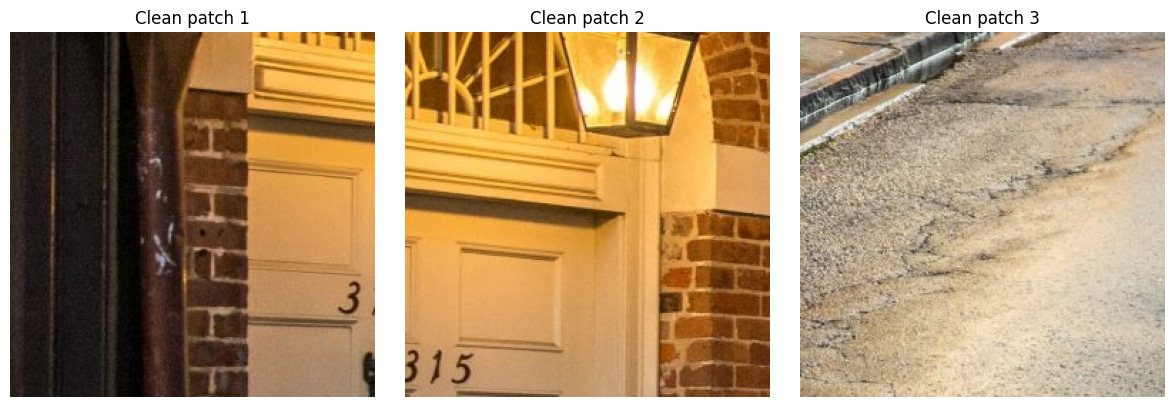

Uploaded image: 756898-2000x1331-desktop-hd-new-orleans-wallpaper-image.jpg
Original image size: (2000, 1331)
Extracted patches: 3


In [18]:
uploaded_file = demo_upload.value[0]

demo_image_name = uploaded_file["name"]
image_data = bytes(uploaded_file["content"])

demo_image = Image.open(io.BytesIO(image_data)).convert("RGB")

demo_width, demo_height = demo_image.size

if demo_width < patch_size or demo_height < patch_size:
    raise ValueError("Uploaded image must be at least 256x256 pixels.")

demo_rng = random.Random(seed + 500)
demo_clean_patches = []

for _ in range(3):
    x = demo_rng.randint(0, demo_width - patch_size)
    y = demo_rng.randint(0, demo_height - patch_size)

    patch = demo_image.crop((x, y, x + patch_size, y + patch_size))
    demo_clean_patches.append(patch)

plt.figure(figsize=(12, 4))

for i, patch in enumerate(demo_clean_patches):
    plt.subplot(1, 3, i + 1)
    plt.imshow(patch)
    plt.title(f"Clean patch {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Uploaded image:", demo_image_name)
print("Original image size:", demo_image.size)
print("Extracted patches:", len(demo_clean_patches))

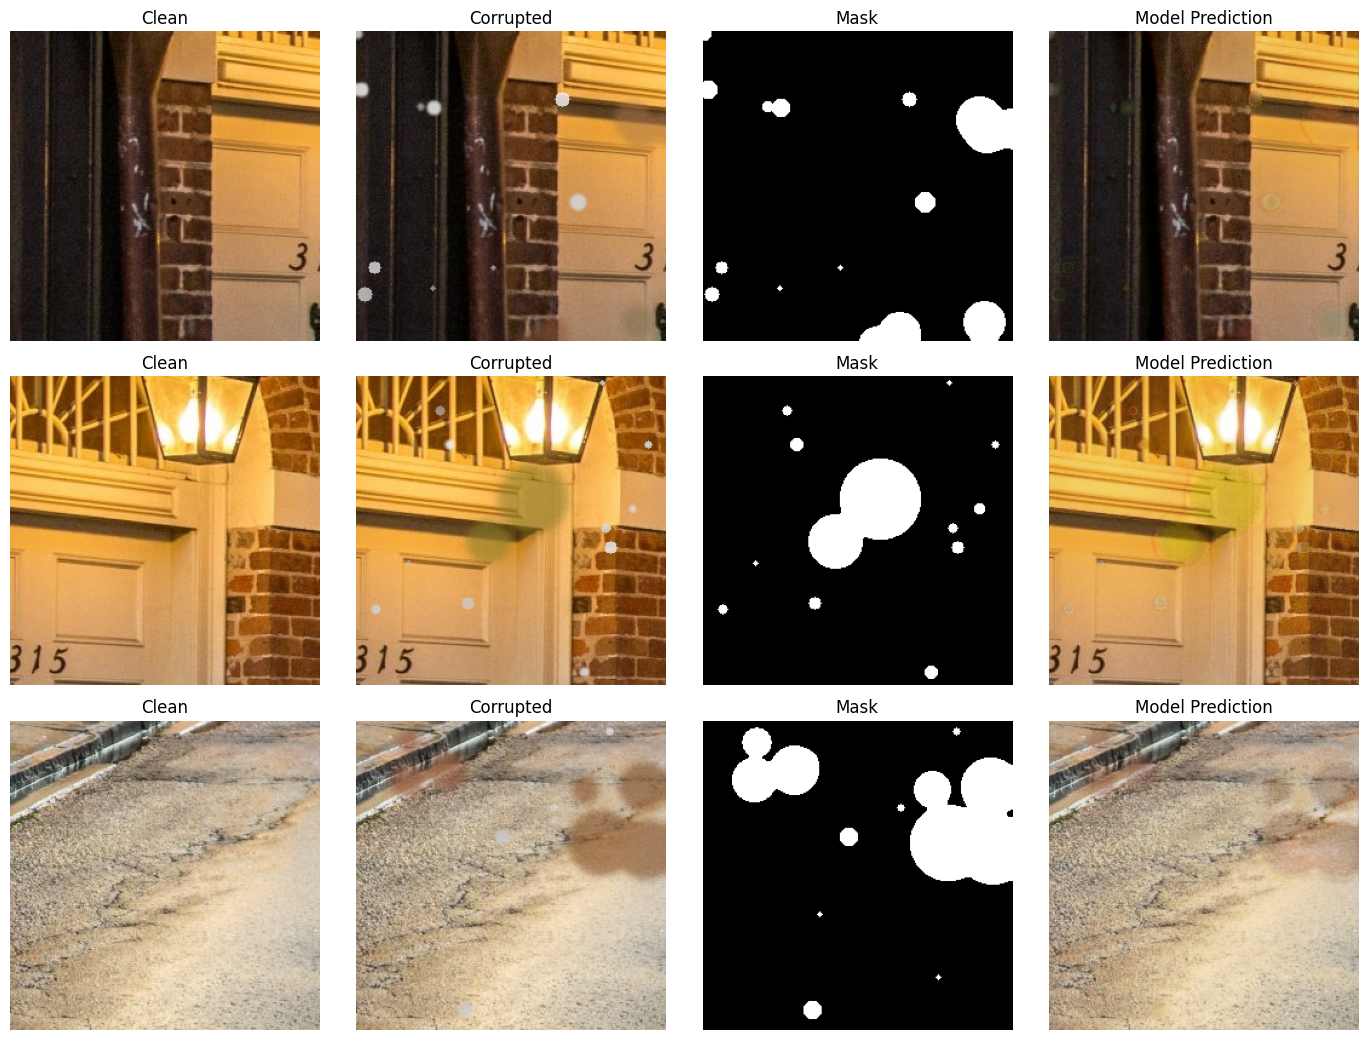

In [20]:
checkpoint = torch.load(best_model_path, map_location=device)

model = SmallUNet(in_channels=4, out_channels=3).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

demo_py_rng = random.Random(seed + 600)
demo_np_rng = np.random.default_rng(seed + 600)

plt.figure(figsize=(14, 3.5 * len(demo_clean_patches)))

for row, clean_patch in enumerate(demo_clean_patches):
    clean_np = np.array(clean_patch.convert("RGB"))

    corrupted_np, mask_np = add_artifacts(clean_np, demo_py_rng, demo_np_rng)

    clean_tensor = torch.from_numpy(clean_np.astype(np.float32) / 255.0).permute(2, 0, 1)
    corrupted_tensor = torch.from_numpy(corrupted_np.astype(np.float32) / 255.0).permute(2, 0, 1)
    mask_tensor = torch.from_numpy(mask_np.astype(np.float32) / 255.0).unsqueeze(0)

    model_input = torch.cat([corrupted_tensor, mask_tensor], dim=0).unsqueeze(0).to(device)

    with torch.no_grad():
        restored = model(model_input).cpu().squeeze(0)

    clean_img = clean_tensor.permute(1, 2, 0).numpy()
    corrupted_img = corrupted_tensor.permute(1, 2, 0).numpy()
    mask_img = mask_tensor.squeeze(0).numpy()
    restored_img = restored.permute(1, 2, 0).numpy()

    plt.subplot(len(demo_clean_patches), 4, row * 4 + 1)
    plt.imshow(clean_img)
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(len(demo_clean_patches), 4, row * 4 + 2)
    plt.imshow(corrupted_img)
    plt.title("Corrupted")
    plt.axis("off")

    plt.subplot(len(demo_clean_patches), 4, row * 4 + 3)
    plt.imshow(mask_img, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(len(demo_clean_patches), 4, row * 4 + 4)
    plt.imshow(restored_img)
    plt.title("Model Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

### References

[1] Agustsson, E., & Timofte, R. (2017).  
NTIRE 2017 Challenge on Single Image Super-Resolution: Dataset and Study.  
[Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition Workshops (CVPRW)](https://openaccess.thecvf.com/content_cvpr_2017_workshops/w12/papers/Agustsson_NTIRE_2017_Challenge_CVPR_2017_paper.pdf).

[2] Quan, W., Chen, J., Liu, Y., Yan, D.-M., & Wonka, P. (2024).  
Deep Learning-based Image and Video Inpainting: A Survey.  
[arXiv:2401.03395](https://arxiv.org/abs/2401.03395).

[3] Wang, Q., He, S., Su, M., & Zhao, F. (2026).  
Image Inpainting Methods: A Review of Deep Learning Approaches.  
[Symmetry, 18(1), 94](https://doi.org/10.3390/sym18010094).